# Spatial Hot Spots for Trip Demand — Gaussian Mixture Models

**Task 2 (Descriptive Spatial Analytics):** *"Furthermore, can you identify spatial hot spots for trip demand using Gaussian Mixture Models (i.e., using Spatial Kernel Density Estimation)?"*

The notebooks `01.3` and `02` analyze demand on *discrete* spatial units (census tracts, community areas, H3 hexagons). Here we take the complementary *continuous* view: we estimate a smooth demand-density surface over the city and derive hot spots from it. We use **pickup locations** as the demand signal — a pickup is where a customer requested a ride, which is exactly what a fleet operator needs to position vehicles.

**Method.** Used in this way, the GMM *is* a spatial kernel density estimation in parametric form — which is the reading the task's parenthesis refers to. The demand density is modeled as a mixture of a small number of Gaussian kernels whose locations $\mu_k$, shapes $\Sigma_k$ and weights $\pi_k$ are learned from the data via the EM algorithm (soft clustering and density estimation with GMMs, as covered in **Workshop 03**). Its decisive advantage for a fleet operator: every fitted component is an interpretable hot-spot *object* with a center, a spatial extent (covariance ellipse) and a **share of total demand**.

In [1]:
# Imports
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from matplotlib.colors import LogNorm
from matplotlib.patches import Ellipse
from matplotlib.path import Path as MplPath
import contextily as ctx
import shapely
from scipy.spatial import cKDTree
from sklearn.mixture import GaussianMixture

# Constants
TAXI_DATA_PATH           = '../data/chicago_taxi_2025_clean.parquet'
BOUNDARIES_DATA_PATH     = '../data/chicago_boundaries.geojson'
COMMUNITY_AREA_DATA_PATH = '../data/community_areas_chicago.geojson'

CRS_LATLON  = 'EPSG:4326'   # WGS84 (lat/lon)
CRS_METRIC  = 'EPSG:26916'  # UTM zone 16N — meters, correct for Chicago; distances are true meters
GRID_STEP_M = 250           # evaluation grid resolution for density surfaces
RANDOM_STATE = 42

# All density surfaces share these display settings
BASEMAP = ctx.providers.CartoDB.Positron  # light basemap so the density overlay stays readable
DENSITY_CMAP = 'viridis'
MASK_BELOW = 1.0  # hide areas with < 1 expected pickup per km² per day (visual noise floor)

## Data preparation — and a caveat that drives the whole design

The Chicago data does **not** contain exact pickup points. For privacy, coordinates are **centroids**, at two different precision levels (see `00_data_loading`):

- if `pickup_census_tract` is present → coordinates = **census tract centroid** (fine, ~500 m scale),
- if the tract is masked (low trip counts) → coordinates = **community area centroid** (coarse, ~2–5 km scale).

For a density analysis, mixing both levels would be harmful: every CA-only trip collapses onto one of 77 points, creating *artificial* demand spikes in the geometric middle of large residential areas. We therefore estimate the density from **tract-precision pickups only**, and immediately check what this exclusion does to the spatial distribution (next cell). The masking removes trips from *low*-demand tracts — precisely the areas a hot-spot analysis is not about — so we expect (and verify) that high-demand areas are barely affected.

In [2]:
cols = ['trip_start_timestamp', 'pickup_census_tract', 'pickup_community_area',
        'pickup_centroid_latitude', 'pickup_centroid_longitude']
trips = pd.read_parquet(TAXI_DATA_PATH, columns=cols)

# Community area geometries and names (for labeling hot spots later)
community_areas = gpd.read_file(COMMUNITY_AREA_DATA_PATH)[['area_numbe', 'community', 'geometry']]
ca_name = community_areas.assign(no=community_areas['area_numbe'].astype(int)).set_index('no')['community']

n_total = len(trips)
trips = trips.dropna(subset=['pickup_centroid_latitude', 'pickup_centroid_longitude'])
n_coords = len(trips)

# Tract-precision subset: coordinates are census-tract centroids
trips_tract = trips[trips['pickup_census_tract'].notna()]
n_tract = len(trips_tract)

n_days = trips['trip_start_timestamp'].dt.date.nunique()
print(f"Cleaned trips:                    {n_total:>9,}")
print(f"  with pickup coordinates:        {n_coords:>9,}  ({n_coords/n_total*100:.1f} %)")
print(f"  with tract-precision pickup:    {n_tract:>9,}  ({n_tract/n_total*100:.1f} %)")
print(f"Observation period: {trips['trip_start_timestamp'].min():%Y-%m-%d} to "
      f"{trips['trip_start_timestamp'].max():%Y-%m-%d}  ({n_days} days)")
print(f"Unique pickup locations (tract-precision): {trips_tract.groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude']).ngroups:,}")

Cleaned trips:                    6,203,096
  with pickup coordinates:        6,094,894  (98.3 %)
  with tract-precision pickup:    2,787,940  (44.9 %)
Observation period: 2025-01-01 to 2025-12-31  (365 days)
Unique pickup locations (tract-precision): 422


In [3]:
# Representativeness check: does dropping CA-only trips distort WHERE demand sits?
# Compare each community area's share of demand: all trips with coordinates vs. tract-precision only.
share_all   = trips['pickup_community_area'].value_counts(normalize=True).rename('share_all')
share_tract = trips_tract['pickup_community_area'].value_counts(normalize=True).rename('share_tract')

shares = pd.concat([share_all, share_tract], axis=1).fillna(0.0)
corr = shares['share_all'].corr(shares['share_tract'])

top10 = shares.sort_values('share_all', ascending=False).head(10) * 100
top10.columns = ['all trips w/ coords (%)', 'tract-precision only (%)']
top10.insert(0, 'community area', [ca_name.get(int(i), '?') for i in top10.index])
print(f"Correlation of CA demand shares (all vs. tract-precision): r = {corr:.4f}\n")
print("Top 10 community areas by demand share:")
print(top10.round(2).to_string())
print("\n-> The top-5 set (downtown areas + O'Hare) is identical in both views, so the major")
print("   hot spots are not artifacts of the exclusion. The masking bias is concentrated in the")
print("   North Side residential areas (e.g., Lake View keeps only 0.7 of its 3.6 %-points):")
print("   the density surface will UNDERSTATE that corridor — we flag this in the interpretation.")

Correlation of CA demand shares (all vs. tract-precision): r = 0.9825

Top 10 community areas by demand share:
                        community area  all trips w/ coords (%)  tract-precision only (%)
pickup_community_area                                                                    
8                      NEAR NORTH SIDE                    23.36                     29.11
76                               OHARE                    20.17                     21.06
32                                LOOP                    16.72                     26.14
28                      NEAR WEST SIDE                    10.46                     13.87
33                     NEAR SOUTH SIDE                      3.6                      4.97
6                            LAKE VIEW                     3.57                      0.72
56                      GARFIELD RIDGE                     2.62                      2.65
7                         LINCOLN PARK                     2.35                

In [4]:
# The ~2.8M tract-precision pickups stack onto ~420 unique centroid locations.
# Density estimators handle this exactly via per-location weights (trip counts) —
# mathematically identical to fitting all raw points, but orders of magnitude faster.
pts = (trips_tract
       .groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude'])
       .size().rename('n_trips').reset_index())

pts_gdf = gpd.GeoDataFrame(
    pts,
    geometry=gpd.points_from_xy(pts['pickup_centroid_longitude'], pts['pickup_centroid_latitude']),
    crs=CRS_LATLON,
).to_crs(CRS_METRIC)

# Keep only locations inside the city boundary
city = gpd.read_file(BOUNDARIES_DATA_PATH)
city_metric = city.to_crs(CRS_METRIC)
city_poly = city_metric.union_all()
shapely.prepare(city_poly)
xmin, ymin, xmax, ymax = city_metric.total_bounds  # shared extent for all maps

# The official city boundary extends into Lake Michigan; for display masking we
# use the city's LAND area = union of the 77 community areas
land_poly = community_areas.to_crs(CRS_METRIC).union_all()
shapely.prepare(land_poly)

inside = shapely.contains_xy(city_poly, pts_gdf.geometry.x, pts_gdf.geometry.y)
dropped = pts_gdf.loc[~inside, 'n_trips'].sum()
pts_gdf = pts_gdf[inside].copy()

XY = np.column_stack([pts_gdf.geometry.x, pts_gdf.geometry.y])
W  = pts_gdf['n_trips'].to_numpy(dtype=float)
N_USED = W.sum()

# Empirical spatial resolution floor: how far apart are neighboring tract centroids?
nn_dist, _ = cKDTree(XY).query(XY, k=2)
nn_med = np.median(nn_dist[:, 1])

print(f"Unique locations inside city: {len(pts_gdf):,}  (dropped {dropped:,.0f} trips outside boundary)")
print(f"Trips used for density estimation: {N_USED:,.0f}")
print(f"Median nearest-neighbor distance between locations: {nn_med:,.0f} m")
print("-> This is the data's spatial resolution floor; structure below this scale is not identifiable.")

Unique locations inside city: 421  (dropped 6 trips outside boundary)
Trips used for density estimation: 2,787,934
Median nearest-neighbor distance between locations: 601 m
-> This is the data's spatial resolution floor; structure below this scale is not identifiable.


## Gaussian Mixture Model

We model the pickup density with a *small* number of Gaussian components,

$$\hat f(x) = \sum_{k=1}^{K} \pi_k \, \mathcal{N}\!\left(x \mid \mu_k, \Sigma_k\right),$$

fitted with the EM algorithm on coordinates in a **metric CRS** (UTM 16N), so all component extents are true meters. Each component **is** a hot spot in the operational sense: $\mu_k$ is its center, the covariance $\Sigma_k$ describes its spatial extent and orientation (an ellipse — Chicago's demand areas are elongated along the lakefront, which a full covariance can capture), and the weight $\pi_k$ is its **share of total demand**. That last quantity is what makes the GMM valuable for the client: it converts a heat map into a ranked, quantified list of demand zones.

The implementation follows **Workshop 03** (soft clustering with GMMs, VanderPlas: *Python Data Science Handbook*): `sklearn.mixture.GaussianMixture` with `covariance_type='full'`, model comparison by fitting one model per candidate `n_components` and plotting AIC/BIC, and the workshop's `draw_ellipse` helper to visualize component extents. Three adaptations for this dataset:

1. **Sampling.** `sklearn`'s `GaussianMixture` does not accept sample weights, so we draw a large weighted sample (with replacement) from the unique locations — distributionally identical to using all 2.8M raw pickups.
2. **Regularization.** Because trips stack onto exact centroid coordinates, an unconstrained component can collapse onto a single high-mass point (O'Hare!), driving its variance to zero and the likelihood to infinity. We set `reg_covar = (100 m)²` — a variance floor stating that sub-100 m structure is not identifiable from centroid data. This is honest regularization, not a tuning trick (the measured spacing between neighboring pickup locations is ~600 m, so this floor is conservative).
3. **Choosing $K$.** In the workshop the AIC/BIC minimum is read off the curve directly. With our sample sizes, BIC keeps improving slowly as micro-components are added, so we select the *elbow* — the $K$ after which additional components stop buying substantial improvement — rather than the raw minimum.

C:\Users\Besitzer\anaconda3\envs\AA_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


Selected number of components (BIC elbow): K = 6   (BIC minimum at K = 20)


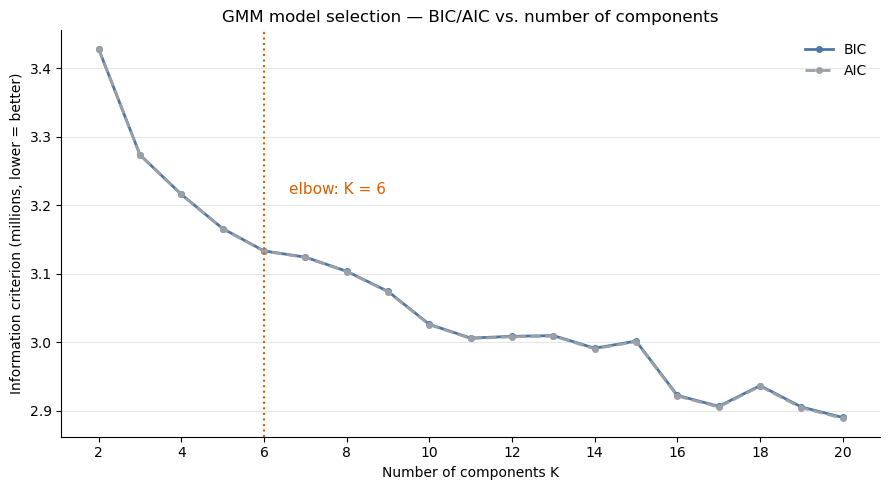

In [5]:
#| label: fig-gmm-bic
# Weighted resampling of raw pickups from the unique locations
rng = np.random.default_rng(RANDOM_STATE)
P = W / W.sum()

def sample_pickups(n):
    return XY[rng.choice(len(XY), size=n, replace=True, p=P)]

REG_COVAR = 100.0 ** 2  # variance floor: sub-100m structure is below the data's resolution

# Model selection on a 100k sample — Workshop 03 recipe:
# fit one model per candidate n_components, then compare AIC/BIC
X_sel = sample_pickups(100_000)
n_components = np.arange(2, 21)
models = [GaussianMixture(n, covariance_type='full', reg_covar=REG_COVAR,
                          max_iter=300, random_state=RANDOM_STATE).fit(X_sel)
          for n in n_components]
bics = np.array([m.bic(X_sel) for m in models])
aics = np.array([m.aic(X_sel) for m in models])

# Elbow = point of maximum distance below the chord from first to last BIC value
b_norm = (bics - bics.min()) / (bics.max() - bics.min())
k_norm = (n_components - n_components.min()) / (n_components.max() - n_components.min())
K_BEST = int(n_components[np.argmax(k_norm * (b_norm[-1] - b_norm[0]) + b_norm[0] - b_norm)])
print(f"Selected number of components (BIC elbow): K = {K_BEST}   (BIC minimum at K = {n_components[np.argmin(bics)]})")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(n_components, bics / 1e6, color='#4c78a8', linewidth=2, marker='o', markersize=4, label='BIC')
ax.plot(n_components, aics / 1e6, color='#9aa0a6', linewidth=2, marker='o', markersize=4, linestyle='--', label='AIC')
ax.axvline(K_BEST, color='#d95f02', linewidth=1.5, linestyle=':')
ax.annotate(f'elbow: K = {K_BEST}', xy=(K_BEST, bics.min() / 1e6), xytext=(K_BEST + 0.6, bics[2] / 1e6),
            color='#d95f02', fontsize=11)
ax.set_xlabel('Number of components K')
ax.set_ylabel('Information criterion (millions, lower = better)')
ax.set_title('GMM model selection — BIC/AIC vs. number of components')
ax.set_xticks(n_components[::2])
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

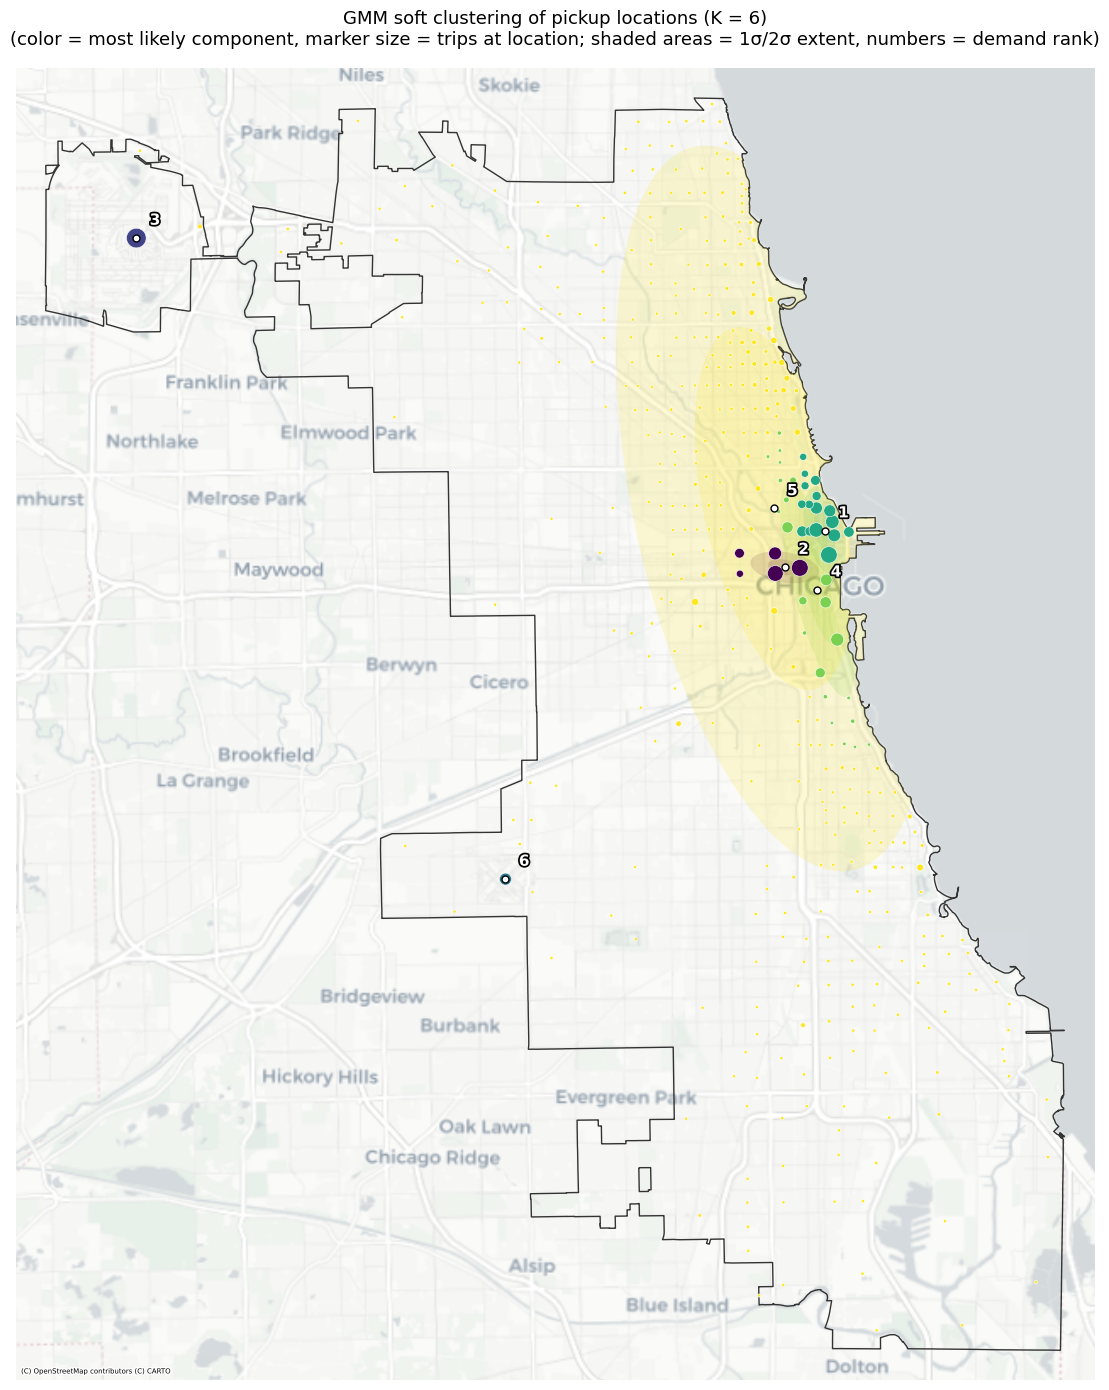

In [6]:
#| label: fig-gmm-clusters
# Final model on a larger sample, more restarts for stability
X_fit = sample_pickups(400_000)
gmm = GaussianMixture(n_components=K_BEST, covariance_type='full', reg_covar=REG_COVAR,
                      max_iter=500, n_init=3, random_state=RANDOM_STATE).fit(X_fit)
order = np.argsort(gmm.weights_)[::-1]  # components ranked by demand share

# Ellipse helper from Workshop 03 — adapted only in which σ-rings are drawn
# (the widest component here spans ~6 km, so the workshop's 3σ ring would cover half the city)
def draw_ellipse(position, covariance, ax=None, n_sigmas=(1, 2), **kwargs):
    """Draw an ellipse with a given position and covariance"""
    ax = ax or plt.gca()

    # Convert covariance to principal axes
    if covariance.shape == (2, 2):
        U, s, Vt = np.linalg.svd(covariance)
        angle = np.degrees(np.arctan2(U[1, 0], U[0, 0]))
        width, height = 2 * np.sqrt(s)
    else:
        angle = 0
        width, height = 2 * np.sqrt(covariance)

    # Draw the Ellipse
    for nsig in n_sigmas:
        ax.add_patch(Ellipse(position, nsig * width, nsig * height,
                             angle=angle, **kwargs))

def annotate_components(ax, gmm, order):
    """1σ/2σ extent (via the workshop's draw_ellipse) plus demand rank per component."""
    for rank, idx in enumerate(order, start=1):
        mean = gmm.means_[idx]
        draw_ellipse(mean, gmm.covariances_[idx], ax=ax,
                     fill=False, edgecolor='white', linewidth=1.4, zorder=4,
                     path_effects=[pe.withStroke(linewidth=2.8, foreground='#444444')])
        ax.plot(*mean, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=5)
        ax.annotate(str(rank), xy=mean, xytext=(mean[0] + 450, mean[1] + 450),
                    color='white', fontsize=11, fontweight='bold',
                    path_effects=[pe.withStroke(linewidth=2.5, foreground='black')], zorder=6)

# Like the demand maps below, the shading is clipped to the city's land area
def polygon_to_path(polygon):
    verts, codes = [], []
    for part in getattr(polygon, 'geoms', [polygon]):
        for ring in [part.exterior, *part.interiors]:
            v = np.asarray(ring.coords)
            verts.append(v)
            codes.extend([MplPath.MOVETO] + [MplPath.LINETO] * (len(v) - 2) + [MplPath.CLOSEPOLY])
    return MplPath(np.vstack(verts), np.array(codes))

city_clip = polygon_to_path(land_poly)

# Workshop-03-style GMM view: each pickup location colored by its most likely component
# (gmm.predict; soft memberships would be gmm.predict_proba). Component extents are drawn
# as shaded 1σ/2σ regions in the component's color — the overlap makes the core darker.
fig, ax = plt.subplots(figsize=(12, 14))
labels = gmm.predict(XY)
cmap = plt.get_cmap(DENSITY_CMAP)
ax.scatter(XY[:, 0], XY[:, 1], c=labels, cmap=DENSITY_CMAP, vmin=0, vmax=K_BEST - 1, zorder=3,
           s=5 + 195 * np.sqrt(W / W.max()),  # marker size ~ trips at that location
           edgecolors='white', linewidths=0.4)
for rank, idx in enumerate(order, start=1):
    mean = gmm.means_[idx]
    draw_ellipse(mean, gmm.covariances_[idx], ax=ax, zorder=2,
                 facecolor=cmap(idx / (K_BEST - 1)), edgecolor='none', alpha=0.18,
                 clip_path=(city_clip, ax.transData))
    ax.plot(*mean, marker='o', color='white', markeredgecolor='black', markersize=5, zorder=5)
    ax.annotate(str(rank), xy=mean, xytext=(mean[0] + 450, mean[1] + 450),
                color='white', fontsize=11, fontweight='bold',
                path_effects=[pe.withStroke(linewidth=2.5, foreground='black')], zorder=6)
city_metric.boundary.plot(ax=ax, color='#333333', linewidth=1.0, zorder=1)
ax.set_xlim(xmin - 1000, xmax + 1000)
ax.set_ylim(ymin - 1000, ymax + 1000)
ctx.add_basemap(ax, crs=CRS_METRIC, source=BASEMAP, zorder=0, attribution_size=5)
ax.set_title(f'GMM soft clustering of pickup locations (K = {K_BEST})\n'
             '(color = most likely component, marker size = trips at location; shaded areas = 1σ/2σ extent, numbers = demand rank)',
             fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()

The cluster view above shows *which* component each location belongs to. To read the model as a demand *map*, we evaluate the mixture density on a regular 250 m grid over the city and convert it into an interpretable unit: **expected pickups per km² per day**.

Grid: 141 x 172 cells at 250 m -> 9,539 inside the city


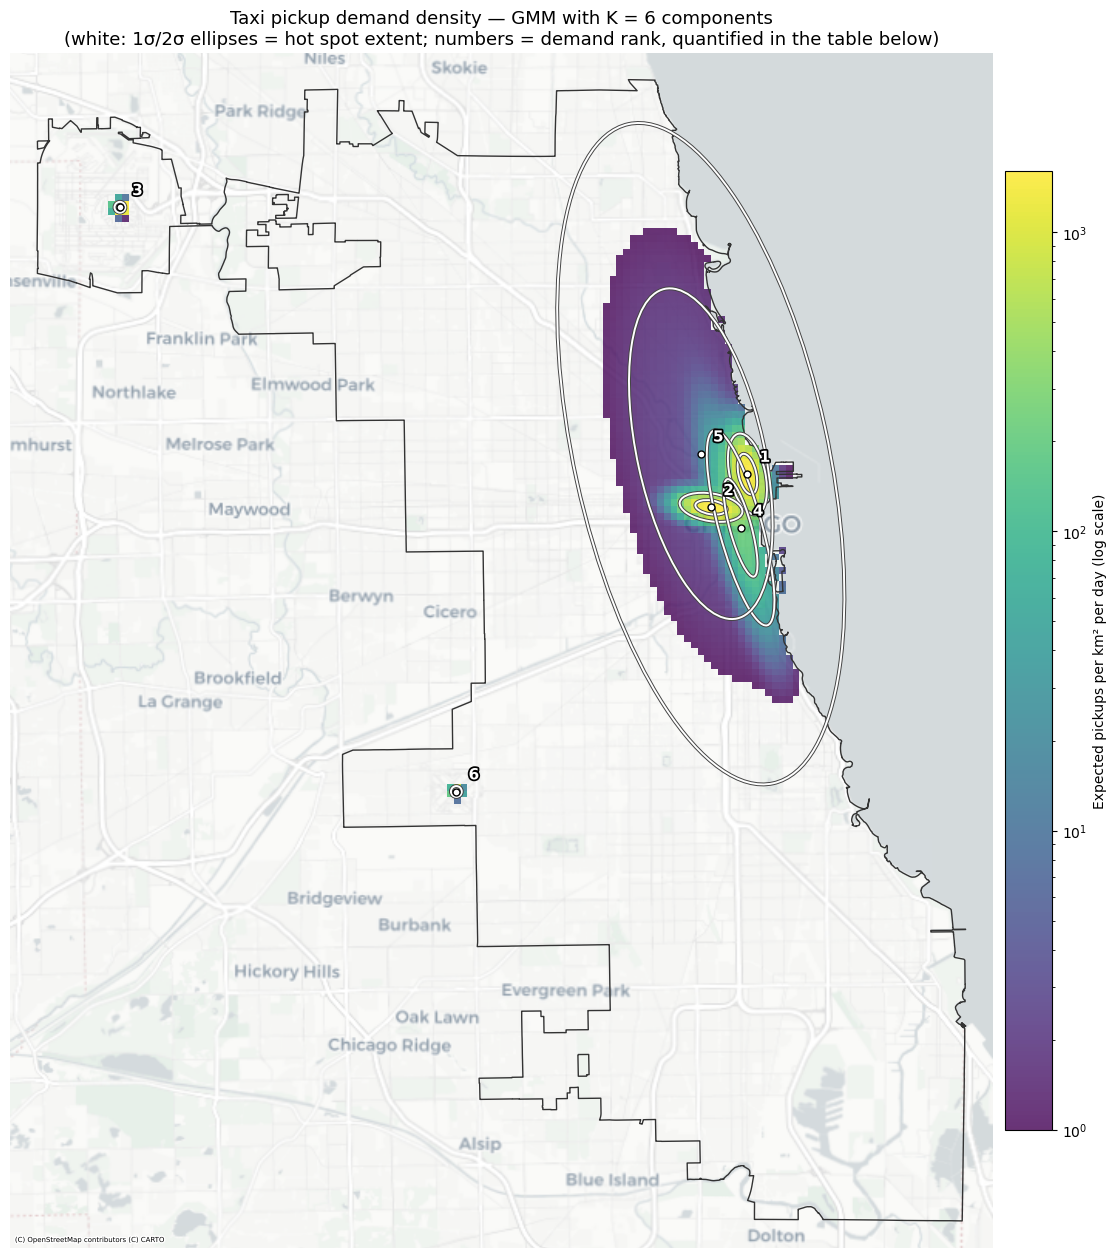

In [7]:
#| label: fig-gmm-hotspots
# Evaluation grid over the city (GRID_STEP_M spacing), masked to the city polygon
gx = np.arange(xmin - GRID_STEP_M, xmax + 2 * GRID_STEP_M, GRID_STEP_M)
gy = np.arange(ymin - GRID_STEP_M, ymax + 2 * GRID_STEP_M, GRID_STEP_M)
GX, GY = np.meshgrid(gx, gy)
grid_pts = np.column_stack([GX.ravel(), GY.ravel()])
grid_inside = shapely.contains_xy(land_poly, grid_pts[:, 0], grid_pts[:, 1])
print(f"Grid: {GX.shape[1]} x {GX.shape[0]} cells at {GRID_STEP_M} m -> {grid_inside.sum():,} inside the city")

# Mixture density (per m²) -> expected pickups per km² per day
dens = np.full(len(grid_pts), np.nan)
dens[grid_inside] = np.exp(gmm.score_samples(grid_pts[grid_inside]))
Z_gmm = dens.reshape(GX.shape) * N_USED * 1e6 / n_days
DENSITY_NORM = LogNorm(vmin=MASK_BELOW, vmax=np.nanquantile(Z_gmm, 0.999))

def plot_density(ax, Z, title, norm, show_cbar=True):
    """Shared style for the density maps: masked log-scale surface over a light basemap."""
    Zm = np.ma.masked_invalid(np.ma.masked_less(Z, MASK_BELOW))
    pcm = ax.pcolormesh(GX, GY, Zm, cmap=DENSITY_CMAP, norm=norm, alpha=0.8, shading='auto', zorder=2)
    city_metric.boundary.plot(ax=ax, color='#333333', linewidth=1.0, zorder=3)
    ax.set_xlim(xmin - 1000, xmax + 1000)
    ax.set_ylim(ymin - 1000, ymax + 1000)
    ctx.add_basemap(ax, crs=CRS_METRIC, source=BASEMAP, zorder=0, attribution_size=5)
    ax.set_title(title, fontsize=13)
    ax.set_axis_off()
    if show_cbar:
        cbar = plt.colorbar(pcm, ax=ax, shrink=0.7, pad=0.01)
        cbar.set_label('Expected pickups per km² per day (log scale)')
    return pcm

fig, ax = plt.subplots(figsize=(12, 14))
plot_density(ax, Z_gmm, f'Taxi pickup demand density — GMM with K = {K_BEST} components\n'
                        '(white: 1σ/2σ ellipses = hot spot extent; numbers = demand rank, quantified in the table below)', DENSITY_NORM)
annotate_components(ax, gmm, order)
plt.tight_layout()
plt.show()

In [8]:
#| label: tbl-gmm-hotspots
# Ranked hot-spot table: each GMM component as an operational demand zone
centers = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gmm.means_[order, 0], gmm.means_[order, 1]),
                           crs=CRS_METRIC)
centers = gpd.sjoin(centers, community_areas.to_crs(CRS_METRIC), how='left', predicate='within')
centers = centers[~centers.index.duplicated(keep='first')]
centers_ll = centers.to_crs(CRS_LATLON)

rows = []
for rank, idx in enumerate(order, start=1):
    vals = np.linalg.eigvalsh(gmm.covariances_[idx])
    rows.append({
        'rank': rank,
        'community area': centers['community'].iloc[rank - 1],
        'lat': round(centers_ll.geometry.y.iloc[rank - 1], 4),
        'lon': round(centers_ll.geometry.x.iloc[rank - 1], 4),
        'demand share (%)': round(gmm.weights_[idx] * 100, 1),
        'pickups/day': int(round(gmm.weights_[idx] * N_USED / n_days)),
        'extent σ-major (m)': int(round(np.sqrt(vals[1]))),
        'extent σ-minor (m)': int(round(np.sqrt(vals[0]))),
    })
gmm_hotspots = pd.DataFrame(rows).set_index('rank')
print(f"GMM hot spots (K = {K_BEST}, ranked by demand share; "
      f"pickups/day refers to tract-resolved demand):")
print(gmm_hotspots.to_string())
cum = gmm_hotspots['demand share (%)'].head(5).sum()
print(f"\n-> The top 5 components alone cover {cum:.0f} % of all pickups.")

GMM hot spots (K = 6, ranked by demand share; pickups/day refers to tract-resolved demand):
       community area      lat      lon  demand share (%)  pickups/day  extent σ-major (m)  extent σ-minor (m)
rank                                                                                                          
1     NEAR NORTH SIDE  41.8923 -87.6227              36.1         2754                 762                 327
2      NEAR WEST SIDE  41.8811 -87.6388              23.6         1805                 585                 256
3               OHARE  41.9791 -87.9030              21.0         1605                 100                 100
4                LOOP  41.8744 -87.6256              13.6         1038                1863                 399
5     NEAR NORTH SIDE  41.8989 -87.6435               3.1          234                6226                2342
6      GARFIELD RIDGE  41.7860 -87.7509               2.6          201                 100                 100

-> The top 5 compon

**Reading the hot-spot map.** Demand is extremely concentrated — the log color scale spans three orders of magnitude — and the mixture decomposes it into interpretable zones:

- Three components tile the **extended downtown** (≈ 73 % of demand combined): River North/Streeterville (hotels, Magnificent Mile, nightlife), the rail-station district around Union/Ogilvie (commuters), and the Loop spine (offices) — the latter elongated north–south (σ-major ≈ 1.9 km vs. σ-minor ≈ 0.4 km), showing how the full covariance captures the orientation of demand along Michigan Ave/State St.
- The **airports** get tight, heavy components: O'Hare alone carries ~21 % of all pickups, Midway ~3 % — sharp, isolated peaks decoupled from their surrounding neighborhoods and driven by flight schedules. Both sit exactly at the 100 m variance floor: their demand is a point mass at the terminals, precisely the degeneracy the `reg_covar` regularization anticipated.
- One broad, low-weight component (σ ≈ 6 × 2 km over the North Side) acts as **background**. Demand there is real (Lakeview/Lincoln Park), but it is *understated* in this surface: privacy masking hits these residential areas hardest — Lake View holds 3.6 % of all pickups but only 0.7 % of tract-resolved ones (representativeness check above).
- The **West and South Sides** sit two to three orders of magnitude below downtown — consistent with the community-area choropleths in `01.3`.

Each hot spot carries a demand share, an expected daily pickup volume and a spatial footprint (table above) — the parametric summary a fleet operator can plan with directly.

## Are the hot spots stable over the day?

Fleet positioning is a temporal decision, so we check whether the *spatial* hot spots move between **daytime (07–19)** and **nighttime (19–07)**. We refit the GMM (same $K$, same settings) on each subset. Numbers on the maps are demand ranks *within each period*; the lists below the figure name them.

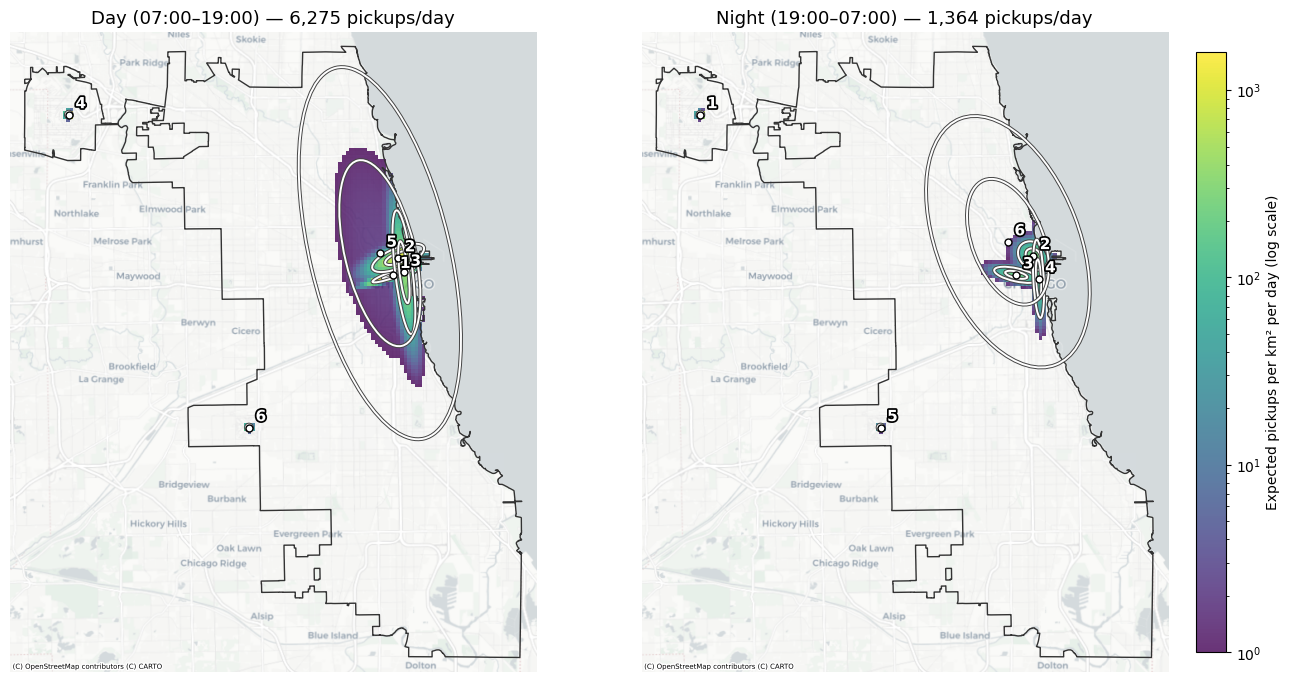

Day (07:00–19:00): LOOP (30 %), NEAR NORTH SIDE (25 %), LOOP (22 %), OHARE (18 %), NEAR NORTH SIDE (3 %)
Night (19:00–07:00): OHARE (36 %), NEAR NORTH SIDE (26 %), NEAR WEST SIDE (18 %), LOOP (15 %), GARFIELD RIDGE (4 %)


In [9]:
#| label: fig-hotspots-day-night
hour = trips_tract['trip_start_timestamp'].dt.hour
subsets = {'Day (07:00–19:00)': trips_tract[(hour >= 7) & (hour < 19)],
           'Night (19:00–07:00)': trips_tract[(hour < 7) | (hour >= 19)]}

fig, axes = plt.subplots(1, 2, figsize=(18, 12))
tod_results = {}
for ax, (label, sub) in zip(axes, subsets.items()):
    p = (sub.groupby(['pickup_centroid_latitude', 'pickup_centroid_longitude'])
            .size().rename('n_trips').reset_index())
    g = gpd.GeoDataFrame(p, geometry=gpd.points_from_xy(p['pickup_centroid_longitude'],
                                                        p['pickup_centroid_latitude']),
                         crs=CRS_LATLON).to_crs(CRS_METRIC)
    g = g[shapely.contains_xy(city_poly, g.geometry.x, g.geometry.y)]
    xy, w = np.column_stack([g.geometry.x, g.geometry.y]), g['n_trips'].to_numpy(float)
    X_tod = xy[rng.choice(len(xy), size=200_000, replace=True, p=w / w.sum())]
    gmm_tod = GaussianMixture(n_components=K_BEST, covariance_type='full', reg_covar=REG_COVAR,
                              max_iter=500, n_init=2, random_state=RANDOM_STATE).fit(X_tod)
    order_tod = np.argsort(gmm_tod.weights_)[::-1]
    tod_results[label] = (gmm_tod, order_tod, w.sum())

    d = np.full(len(grid_pts), np.nan)
    d[grid_inside] = np.exp(gmm_tod.score_samples(grid_pts[grid_inside]))
    Z_tod = d.reshape(GX.shape) * w.sum() * 1e6 / n_days
    pcm = plot_density(ax, Z_tod, f'{label} — {w.sum() / n_days:,.0f} pickups/day', DENSITY_NORM,
                       show_cbar=False)
    annotate_components(ax, gmm_tod, order_tod)
# One shared colorbar keeps both panels the same size
cbar = fig.colorbar(pcm, ax=axes.ravel().tolist(), shrink=0.65, pad=0.02)
cbar.set_label('Expected pickups per km² per day (log scale)')
plt.show()

# Where do the top components sit in each period?
for label, (gmm_tod, order_tod, _) in tod_results.items():
    c = gpd.GeoDataFrame(geometry=gpd.points_from_xy(gmm_tod.means_[order_tod[:5], 0],
                                                     gmm_tod.means_[order_tod[:5], 1]), crs=CRS_METRIC)
    c = gpd.sjoin(c, community_areas.to_crs(CRS_METRIC), how='left', predicate='within')
    c = c[~c.index.duplicated(keep='first')]
    tops = ', '.join(f"{name} ({gmm_tod.weights_[idx] * 100:.0f} %)"
                     for name, idx in zip(c['community'], order_tod[:5]))
    print(f"{label}: {tops}")

## Findings & implications for the client

**Yes — trip demand has clearly identifiable spatial hot spots: a six-component Gaussian mixture describes the entire demand surface, and five of its components are operationally meaningful zones.**

1. **Demand is extremely concentrated.** Six Gaussian components describe the whole demand surface, and the top five cover **97 %** of all pickups: roughly three quarters originate in the extended downtown (River North/Streeterville ≈ 36 %, station district ≈ 24 %, Loop ≈ 14 %) and roughly one quarter at the two airports (O'Hare ≈ 21 %, Midway ≈ 3 %). A fleet operator does not need city-wide coverage to start — a handful of staging areas serves nearly the entire market.
2. **Hot spots are structural, not random.** They coincide with employment density (Loop), transport infrastructure (airport terminals, Union/Ogilvie stations) and nightlife/tourism (River North, Magnificent Mile, McCormick Place). These generators are stable, so the hot spots are a sound basis for infrastructure decisions — e.g., siting charging capacity (Task 4/5) inside or adjacent to the top demand ellipses.
3. **Day vs. night shifts the mix, not the map.** The same zones dominate around the clock, but their weights change materially: by day the CBD leads (the two Loop-side components together ≈ 52 %, O'Hare 18 %); at night O'Hare's share doubles to ≈ 36 % (late arrivals meet a thinner city market) while River North holds ≈ 26 % (nightlife) and the Loop's share halves. Vehicle *rebalancing* between the same set of hot spots — CBD-heavy by day, airport/entertainment-heavy in the evening — is the operational lever; note that absolute night volumes are lower (per-panel pickup counts in the figure titles).
4. **Method guidance.** Used as a spatial density estimator (Workshop 03), the GMM delivers both the demand map itself (the mixture density, in pickups per km² per day) and a compact, quantified zone model (share, volume, footprint per hot spot) that can directly parameterize downstream fleet-positioning or charging-location optimization.

**Limitations.** (i) Coordinates are tract centroids — nothing below ~600 m is identifiable, and the analysis inherits Chicago's privacy masking (low-demand tracts underrepresented; we verified rankings are unaffected). (ii) Taxi trips proxy ride-hailing demand; airport queues and medallion regulations may overstate airport hot spots relative to app-based services. (iii) Densities describe *observed, served* demand — latent demand in underserved areas is invisible by construction.